In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, recall_score, precision_score, roc_curve, auc


In [6]:
data = pd.read_csv('../data/Telco_Customer_Churn.csv')
data.shape

(7043, 21)

In [7]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
original_rows = len(data)
data = data.dropna(subset=['TotalCharges'])
print(f"Total dropped rows with NaNs: {original_rows - len(data)}")

Total dropped rows with NaNs: 11


In [10]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
      'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

In [12]:
X = data[numeric_features + categorical_features]
y = data[target_feature]

In [13]:
from collections import Counter
Counter(y)
#The data is imbalanced since yes and no are not 50-50

Counter({'No': 5163, 'Yes': 1869})

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify=y)
#In train_test_split, the stratify parameter ensures that the proportions of class labels in the training and testing sets are approximately the same as the proportions in the original dataset.

In [15]:
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})
y = y.map({'Yes': 1, 'No': 0})


In [16]:
print(f"Original data churn rate: {y.mean():.2f}")
print(f"Training data churn rate: {y_train.mean():.2f}")
print(f"Testing data churn rate: {y_test.mean():.2f}")

Original data churn rate: 0.27
Training data churn rate: 0.27
Testing data churn rate: 0.27


In [17]:
from sklearn.compose import ColumnTransformer
# Numeric Preprocessing Batch

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical Preprocessing Batch

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# Combine both batches with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)

    ],
    remainder = 'drop'
)

# Create the final, full-stack pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight = 'balanced',
        random_state = 42,

    ))
])


In [18]:
clf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[1 0 1 ... 0 1 0]


In [20]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
print(y_proba)


[0.5112015  0.26977867 0.5284545  ... 0.0934443  0.64519062 0.07832672]


In [21]:
print(recall_score(y_test, y_predict))


0.8270944741532977


In [22]:
print(confusion_matrix(y_test, y_predict))

[[1129  420]
 [  97  464]]


In [23]:
print(precision_score(y_test, y_predict))

0.5248868778280543


In [24]:
print(accuracy_score(y_test, y_predict))

0.7549763033175355


In [25]:
print(f1_score(y_test, y_predict))

0.6422145328719723


In [26]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1549
           1       0.52      0.83      0.64       561

    accuracy                           0.75      2110
   macro avg       0.72      0.78      0.73      2110
weighted avg       0.82      0.75      0.77      2110



In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8528128664459503


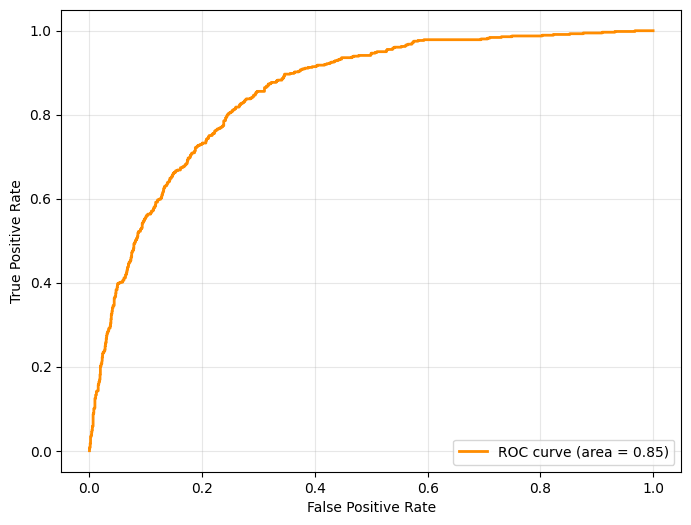

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [29]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators = 200,
        class_weight = 'balanced',
        random_state = 42,

    ))
])

In [30]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.63      0.47      0.54       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.79      0.78      2110



In [33]:
print(confusion_matrix(y_test, y_pred_rf))

[[1395  154]
 [ 295  266]]


In [34]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)

0.8245558919618085


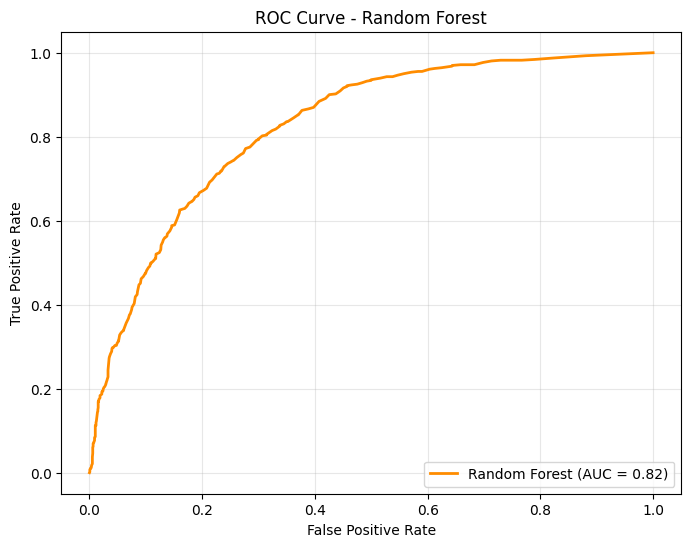

In [35]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [36]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    clf_pipeline, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Logistic Regression CV AUC:", cv_auc.mean())

Logistic Regression CV AUC: 0.8400245125188304


In [37]:
cv_auc = cross_val_score(
    rf_model, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Random Forest CV AUC:", cv_auc.mean())

Random Forest CV AUC: 0.8202413900825881


In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

In [39]:
grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=   2.1s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=   2.1s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   2.3s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   2.3s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   2.3s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=   2.1s
[CV] END model__max_depth=None, model__min_samples_leaf=5, model__min_samples_split=2, model__n_estimators=200; total time=   2.0s
[CV] END model__max

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 5], 'model__min_samples_split': [2, 10], 'model__n_estimators': [200, 400]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [40]:
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

Best RF Params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best RF CV AUC: 0.8419353110106624


In [41]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


0.8525372588145534
0.7734597156398104
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1549
           1       0.55      0.75      0.64       561

    accuracy                           0.77      2110
   macro avg       0.73      0.77      0.74      2110
weighted avg       0.81      0.77      0.78      2110



In [42]:

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(15)

,feature,importance
2,num__tenure,0.131998
37,cat__Contract_Month-to-month,0.121648
1,num__TotalCharges,0.103690
0,num__MonthlyCharges,0.070358
39,cat__Contract_Two year,0.065773
19,cat__OnlineSecurity_No,0.052187
28,cat__TechSupport_No,0.052099
17,cat__InternetService_Fiber optic,0.042018
44,cat__PaymentMethod_Electronic check,0.028149
38,cat__Contract_One year,0.019566


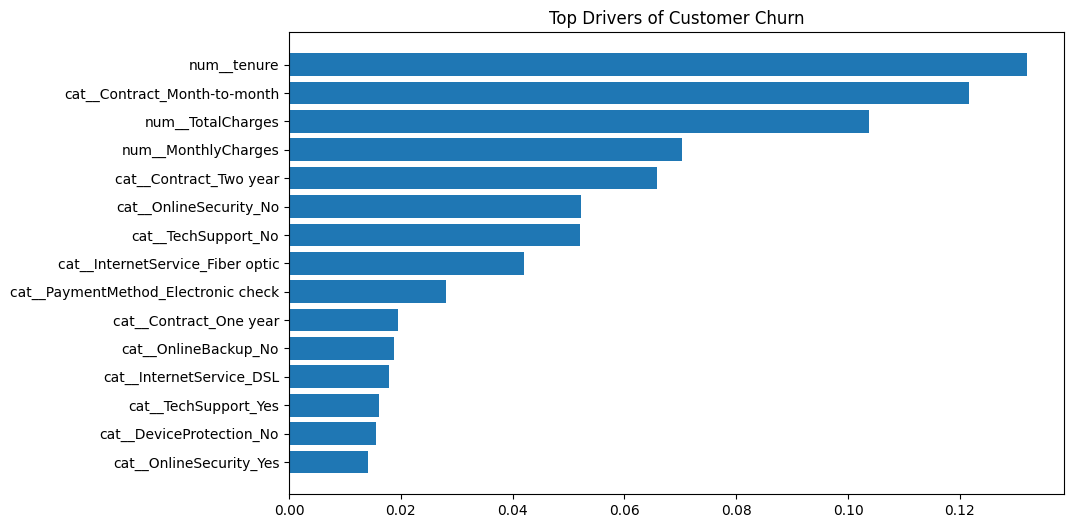

In [43]:

top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Customer Churn")
plt.show()

In [44]:

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_proba_rf >= t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
results_df

,threshold,precision,recall,f1
0,0.10,0.339275,0.983957,0.504570
1,0.15,0.361660,0.978610,0.528139
2,0.20,0.388252,0.966132,0.553909
3,0.25,0.416275,0.948307,0.578575
4,0.30,0.446074,0.921569,0.601163
5,0.35,0.484556,0.894831,0.628679
6,0.40,0.507415,0.853832,0.636545
7,0.45,0.528522,0.809269,0.639437
8,0.50,0.554822,0.748663,0.637329
9,0.55,0.581979,0.702317,0.636511


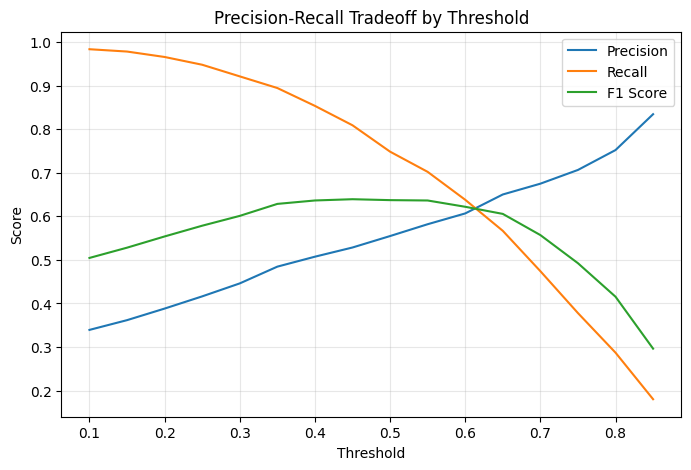

In [45]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall Tradeoff by Threshold")
plt.grid(alpha=0.3)
plt.show()

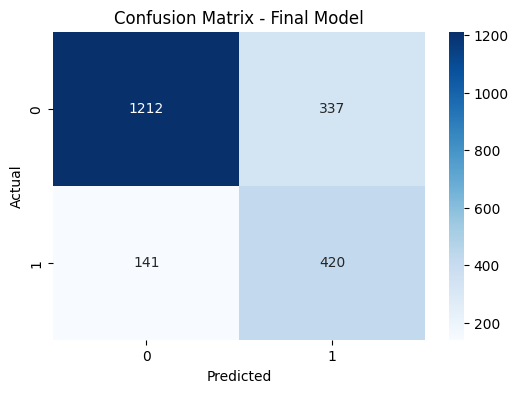

In [46]:
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

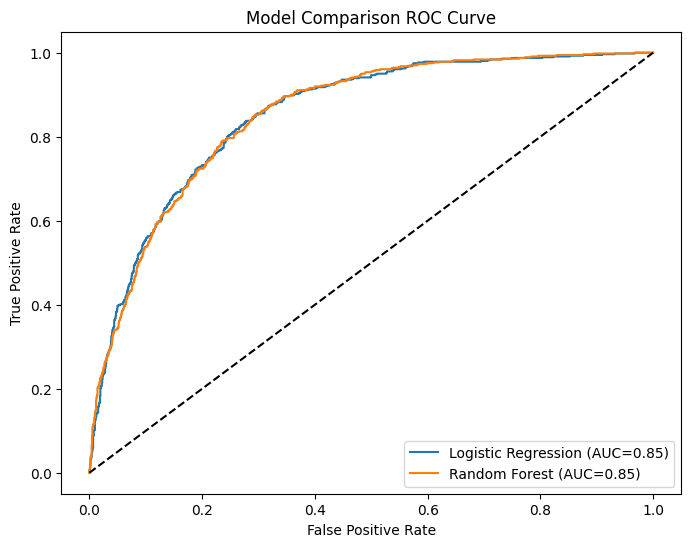

In [47]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()

In [48]:
churn_prob = y_pred_proba_rf

risk_df = pd.DataFrame({
    "churn_probability": churn_prob
})

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

risk_df["risk_level"].value_counts()

risk_level
Low Risk       951
High Risk      590
Medium Risk    569
Name: count, dtype: int64

In [49]:
import joblib

joblib.dump(clf_pipeline, "logistic_model.pkl")
joblib.dump(best_rf, "rf_model.pkl")

['rf_model.pkl']

In [50]:
import sklearn
print(sklearn.__version__)

1.7.2
